In [1]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import kpss
from scipy.stats import ks_2samp
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import statsmodels.api as sm
from pylab import rcParams
import plotly.express as px
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# E-Today(KWH) Forecasting

In [2]:
df=pd.read_csv("d:\\solar-performance-monitoring\\data\\interim\\Preprocessing_data\\df_unit.csv")
df["date"]=pd.to_datetime(df["date"])
df.describe()

,date,E-Today(KWH)
count,507,507.000000
mean,2025-07-26 21:01:03.905325568,33.376726
min,2024-11-16 00:00:00,1.000000
25%,2025-03-22 12:00:00,23.000000
50%,2025-07-27 00:00:00,33.000000
75%,2025-11-30 12:00:00,45.000000
max,2026-04-05 00:00:00,62.000000
std,NaN,14.177938


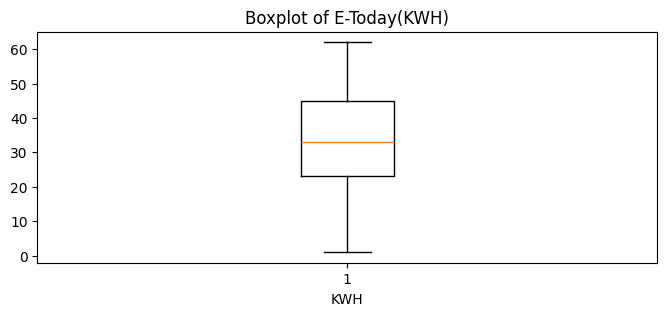

In [4]:
plt.figure(figsize=(8, 3))
plt.boxplot(df["E-Today(KWH)"].dropna())

plt.title("Boxplot of E-Today(KWH)")
plt.xlabel("KWH")
plt.show()

# check Stationarity 

In [ ]:
# make data stationary 
# log 
# sqrt
# dff
# boxcox

In [ ]:
def adf_test(df):
    result = adfuller(df)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    if result[1] <= 0.05:
        print("Reject the null hypothesis. Data is stationary")
    else:
        print("Fail to reject the null hypothesis. Data is not stationary")

adf_test(df['E-Today(KWH)'].diff().dropna())

ADF Statistic: -10.290373
p-value: 0.000000
Reject the null hypothesis. Data is stationary


In [ ]:
statistic, p_value, lags, critical_values = kpss(df['E-Today(KWH)'], regression='c', nlags="auto")

print(f"KPSS Statistic: {statistic}")
print(f"p-value: {p_value}")
print(f"Number of lags: {lags}")


# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis → Series is NOT stationary")
else:
    print("Fail to reject the null hypothesis → Series is stationary")

KPSS Statistic: 0.959945715722851
p-value: 0.01
Number of lags: 11
Reject the null hypothesis → Series is NOT stationary


C:\Users\turab\AppData\Local\Temp\ipykernel_18336\1173518367.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(df['E-Today(KWH)'], regression='c', nlags="auto")


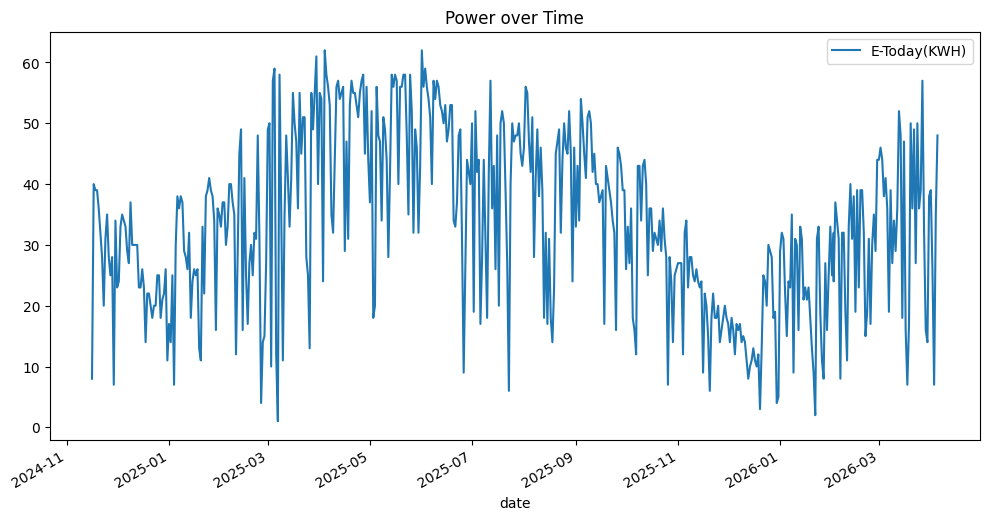

In [ ]:
df.plot(x='date', y='E-Today(KWH)', kind='line', figsize=(12, 6))


plt.title('Power over Time')
plt.show()

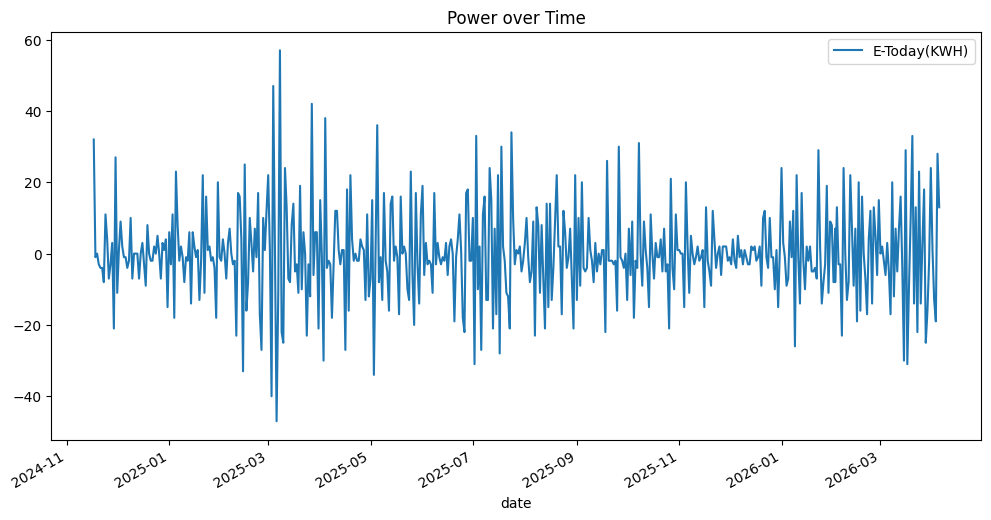

In [ ]:
temp=df.copy()
temp["E-Today(KWH)"]=temp["E-Today(KWH)"].diff().dropna()
temp.plot(x='date', y='E-Today(KWH)', kind='line', figsize=(12, 6))
plt.title('Power over Time')
plt.show()

# ACF and PACF plots

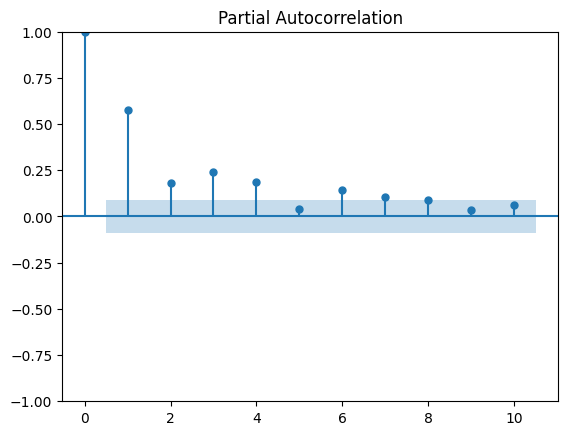

In [ ]:
plot_pacf(df["E-Today(KWH)"], lags=10)
plt.show()

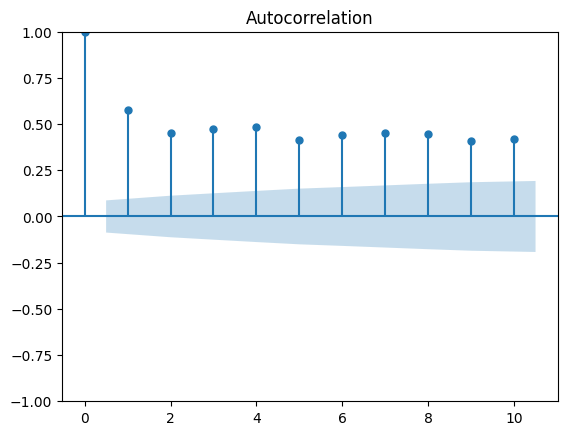

In [ ]:
plot_acf(df["E-Today(KWH)"], lags=10)
plt.show()

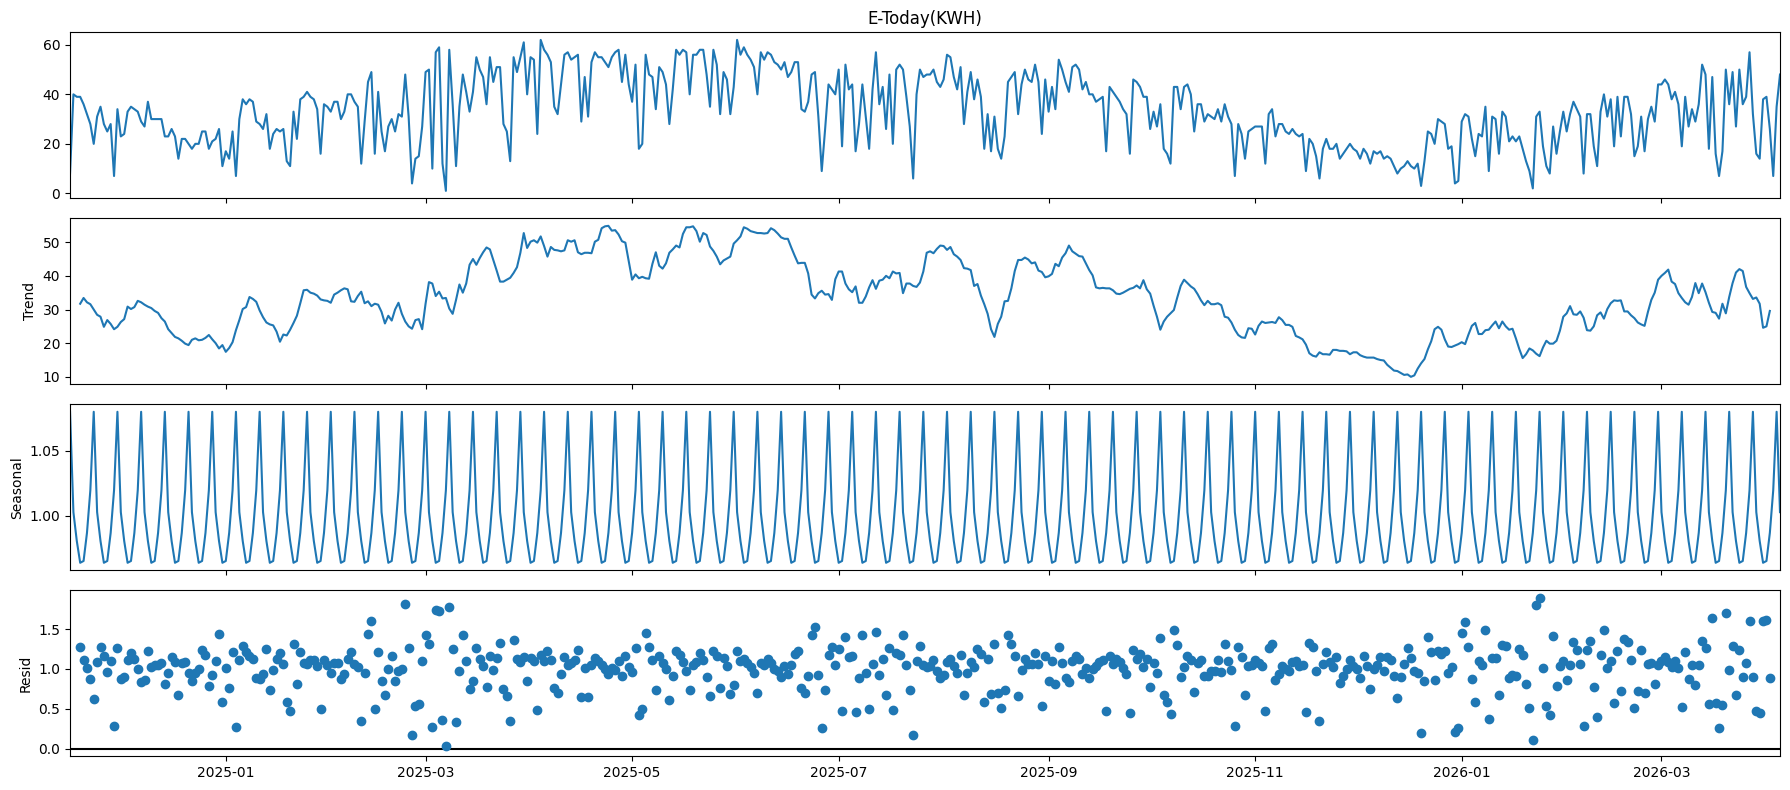

In [ ]:

rcParams['figure.figsize'] = 18, 8
ts = df.drop_duplicates(subset=['date']).set_index('date').asfreq('D')['E-Today(KWH)']

decomposition = sm.tsa.seasonal_decompose(ts, model='multiplicative')
fig = decomposition.plot()
plt.show()

 ## SARIMA

In [ ]:
# Function to calculate metrics
def calculate_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mse, rmse, mae, mape

In [ ]:
# -------------------------
# Train-test split (80/20)
train_size = int(len(df) * 0.80)
train = df['E-Today(KWH)'][:train_size]
test = df['E-Today(KWH)'][train_size:]

In [45]:

# -------------------------
# SARIMA parameters (FINAL)
p, d, q = 1, 1, 1
P, D, Q, s = 2, 1, 0,4

# -------------------------
# Fit model on TRAIN only
sarima_model = SARIMAX(
    train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

In [46]:
# -------------------------
# Forecast for TEST period
sarima_forecast = sarima_result.forecast(steps=len(test))

# -------------------------
# Calculate error metrics (TEST set)
mse, rmse, mae, mape = calculate_metrics(test, sarima_forecast)

print("\nSARIMA Test Set Error Metrics:")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"MAPE: {mape:.2f}%")


SARIMA Test Set Error Metrics:
MSE: 272.063
RMSE: 16.494
MAE: 13.539
MAPE: 60.12%


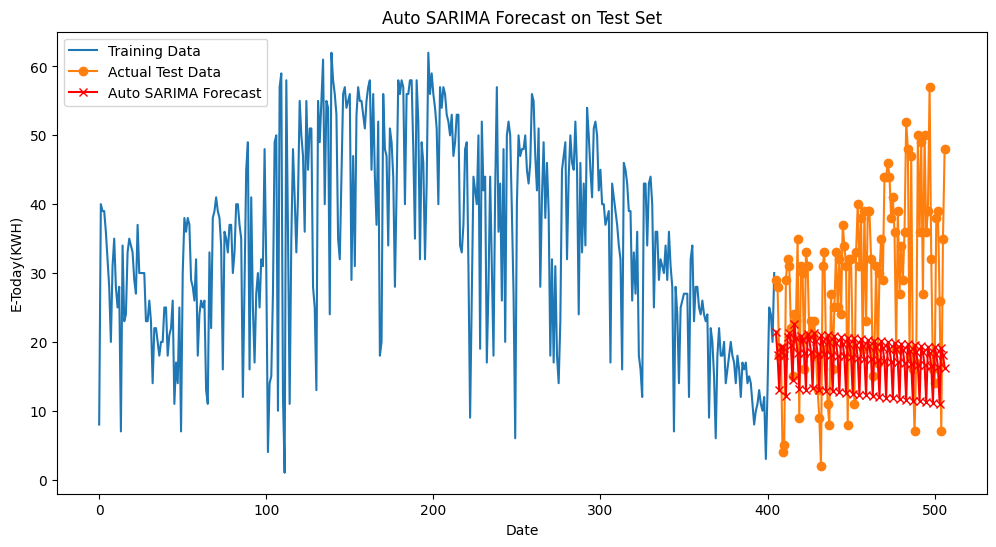

In [47]:
# -------------------------
# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data', marker='o')
plt.plot(test.index, sarima_forecast, color='red', label='Auto SARIMA Forecast', marker='x')
plt.title('Auto SARIMA Forecast on Test Set')
plt.xlabel('Date')
plt.ylabel('E-Today(KWH)')
plt.legend()
plt.show()

In [ ]:
forecast = sarima_result.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()


last_date = df["date"].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=3)
forecast_mean.index = future_dates
forecast_ci.index = future_dates
# -------------------------
# Print forecast
print("3-Day Solar KWH Forecast (SARIMA):")
print(forecast_mean)
print("\nConfidence Intervals:")
print(forecast_ci)

3-Day Solar KWH Forecast (SARIMA):
2026-04-06    30.375722
2026-04-07    31.615411
2026-04-08    34.862233
Freq: D, Name: predicted_mean, dtype: float64

Confidence Intervals:
            lower E-Today(KWH)  upper E-Today(KWH)
2026-04-06       -8.419211e+08        8.419212e+08
2026-04-07       -9.151254e+08        9.151254e+08
2026-04-08       -9.267539e+08        9.267540e+08


# Auto Arima

In [55]:

# # -------------------------
# # Fit Auto SARIMA on training data
auto_sarima = auto_arima(
    train,
    seasonal=True,
    m=30,                 # weekly seasonality
    start_p=1, max_p=2,
    start_q=1, max_q=2,
    start_P=1, max_P=2,
    start_Q=1, max_Q=2,
    d=1, D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True        # FAST + SAFE
)

print("\nBest SARIMA model order:", auto_sarima.order, "seasonal_order:", auto_sarima.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[30]             : AIC=inf, Time=15.00 sec
 ARIMA(0,1,0)(0,1,0)[30]             : AIC=3242.284, Time=0.12 sec
 ARIMA(1,1,0)(1,1,0)[30]             : AIC=3126.985, Time=1.28 sec
 ARIMA(0,1,1)(0,1,1)[30]             : AIC=inf, Time=6.75 sec
 ARIMA(1,1,0)(0,1,0)[30]             : AIC=3200.246, Time=0.32 sec
 ARIMA(1,1,0)(2,1,0)[30]             : AIC=3087.605, Time=8.13 sec


KeyboardInterrupt: 

In [54]:
# # -------------------------
# # Forecast on test set
n_test = len(test)
sarima_forecast = auto_sarima.predict(n_periods=n_test)

mse, rmse, mae, mape = calculate_metrics(test, sarima_forecast)
print("\nAuto SARIMA Test Set Error Metrics:")
print(f"MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.2f}%")


Auto SARIMA Test Set Error Metrics:
MSE: 908.038, RMSE: 30.134, MAE: 26.220, MAPE: 89.61%


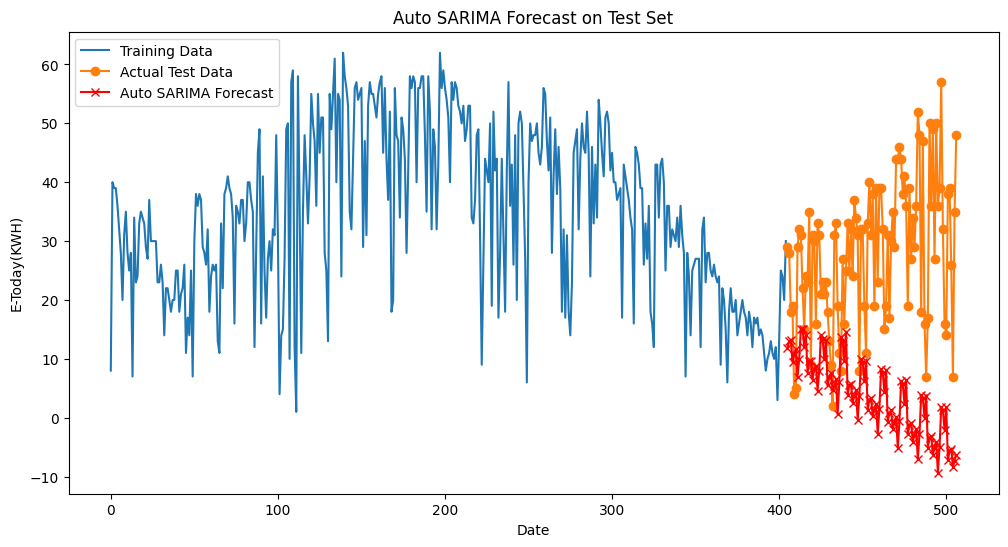

In [35]:
# -------------------------
# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data', marker='o')
plt.plot(test.index, sarima_forecast, color='red', label='Auto SARIMA Forecast', marker='x')
plt.title('Auto SARIMA Forecast on Test Set')
plt.xlabel('Date')
plt.ylabel('E-Today(KWH)')
plt.legend()
plt.show()

In [33]:
forecast = sarima_result.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()


last_date = df["date"].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=3)
forecast_mean.index = future_dates
forecast_ci.index = future_dates
# -------------------------
# Print forecast
print("3-Day Solar KWH Forecast (SARIMA):")
print(forecast_mean)
print("\nConfidence Intervals:")
print(forecast_ci)

3-Day Solar KWH Forecast (SARIMA):
2026-04-06    30.375722
2026-04-07    31.615411
2026-04-08    34.862233
Freq: D, Name: predicted_mean, dtype: float64

Confidence Intervals:
            lower E-Today(KWH)  upper E-Today(KWH)
2026-04-06       -8.419211e+08        8.419212e+08
2026-04-07       -9.151254e+08        9.151254e+08
2026-04-08       -9.267539e+08        9.267540e+08


# Ml Models

In [1]:
import pandas as pd
df=pd.read_csv("d:\\solar-performance-monitoring\\data\\interim\\Preprocessing_data\\df_unit.csv")
df["date"]=pd.to_datetime(df["date"])
df.describe()

,date,E-Today(KWH)
count,507,507.000000
mean,2025-07-26 21:01:03.905325,33.376726
min,2024-11-16 00:00:00,1.000000
25%,2025-03-22 12:00:00,23.000000
50%,2025-07-27 00:00:00,33.000000
75%,2025-11-30 12:00:00,45.000000
max,2026-04-05 00:00:00,62.000000
std,NaN,14.177938


In [2]:
import pandas as pd
import numpy as np



# -------------------------
# BASIC TIME FEATURES
# -------------------------

df['month'] = df['date'].dt.month

# -------------------------
# CYCLICAL FEATURES (IMPORTANT)
# -------------------------
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)



# -------------------------
# LAG FEATURES (CORE)
# -------------------------
df['lag1'] = df['E-Today(KWH)'].shift(1)
df['lag2'] = df['E-Today(KWH)'].shift(2)


# -------------------------
# ROLLING FEATURES
# -------------------------
df['roll_mean_3'] = df['E-Today(KWH)'].rolling(3).mean()
df['roll_mean_7'] = df['E-Today(KWH)'].rolling(7).mean()



df['roll_max_7'] = df['E-Today(KWH)'].rolling(7).max()
df['roll_min_7'] = df['E-Today(KWH)'].rolling(7).min()

# -------------------------
# TREND FEATURES
# -------------------------
df['diff1'] = df['E-Today(KWH)'].diff(1)
df['diff7'] = df['E-Today(KWH)'].diff(7)

# -------------------------
# NOT USE FEATURE
# -------------------------
# df['expanding_mean'] = df['E-Today(KWH)'].expanding().mean()
# df['roll_std_7'] = df['E-Today(KWH)'].rolling(7).std()
# df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
# df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
# df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)


# -------------------------
# INTERACTION FEATURE
# -------------------------
df['lag1_roll7'] = df['lag1'] * df['roll_mean_7']

# -------------------------
# DROP NA
# -------------------------
df = df.dropna()

df

,date,E-Today(KWH),month,month_cos,lag1,lag2,roll_mean_3,roll_mean_7,roll_max_7,roll_min_7,diff1,diff7,lag1_roll7
7,2024-11-23,20,11,0.866025,28.0,32.0,26.666667,33.428571,40.0,20.0,-8.0,12.0,936.000000
8,2024-11-24,31,11,0.866025,20.0,28.0,26.333333,32.142857,39.0,20.0,11.0,-9.0,642.857143
9,2024-11-25,35,11,0.866025,31.0,20.0,28.666667,31.571429,39.0,20.0,4.0,-4.0,978.714286
10,2024-11-26,28,11,0.866025,35.0,31.0,31.333333,30.000000,36.0,20.0,-7.0,-11.0,1050.000000
11,2024-11-27,25,11,0.866025,28.0,35.0,29.333333,28.428571,35.0,20.0,-3.0,-11.0,796.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,2026-04-01,39,4,-0.500000,38.0,14.0,30.333333,33.571429,57.0,14.0,1.0,3.0,1275.714286
503,2026-04-02,26,4,-0.500000,39.0,38.0,34.333333,31.714286,57.0,14.0,-13.0,-13.0,1236.857143
504,2026-04-03,7,4,-0.500000,26.0,39.0,24.000000,24.571429,39.0,7.0,-19.0,-50.0,638.857143
505,2026-04-04,35,4,-0.500000,7.0,26.0,22.666667,25.000000,39.0,7.0,28.0,3.0,175.000000


In [6]:
# -------------------------
# FINAL INPUT FEATURES
# -------------------------
X = df.drop(['date', 'E-Today(KWH)', 'month',"roll_mean_7"], axis=1)
y = df['E-Today(KWH)']
X

,month_cos,lag1,lag2,roll_mean_3,roll_max_7,roll_min_7,diff1,diff7,lag1_roll7
7,0.866025,28.0,32.0,26.666667,40.0,20.0,-8.0,12.0,936.000000
8,0.866025,20.0,28.0,26.333333,39.0,20.0,11.0,-9.0,642.857143
9,0.866025,31.0,20.0,28.666667,39.0,20.0,4.0,-4.0,978.714286
10,0.866025,35.0,31.0,31.333333,36.0,20.0,-7.0,-11.0,1050.000000
11,0.866025,28.0,35.0,29.333333,35.0,20.0,-3.0,-11.0,796.000000
...,...,...,...,...,...,...,...,...,...
502,-0.500000,38.0,14.0,30.333333,57.0,14.0,1.0,3.0,1275.714286
503,-0.500000,39.0,38.0,34.333333,57.0,14.0,-13.0,-13.0,1236.857143
504,-0.500000,26.0,39.0,24.000000,39.0,7.0,-19.0,-50.0,638.857143
505,-0.500000,7.0,26.0,22.666667,39.0,7.0,28.0,3.0,175.000000


In [7]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

X_train = train.drop(['date', 'E-Today(KWH)', 'month',"roll_mean_7"], axis=1)
y_train = train['E-Today(KWH)']

X_test = test.drop(['date', 'E-Today(KWH)', 'month',"roll_mean_7"], axis=1)
y_test = test['E-Today(KWH)']

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=42,min_samples_split=5,
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
# Get importance
rf_importance = rf_model.feature_importances_

# Create dataframe
rf_feat = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importance
}).sort_values(by='Importance', ascending=False)

print(rf_feat)

       Feature  Importance
3  roll_mean_3    0.677595
6        diff1    0.197138
4   roll_max_7    0.038371
2         lag2    0.028025
7        diff7    0.019185
1         lag1    0.015402
5   roll_min_7    0.011550
8   lag1_roll7    0.009243
0    month_cos    0.003490


In [9]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_importance = xgb_model.feature_importances_

xgb_feat = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importance
}).sort_values(by='Importance', ascending=False)

print(xgb_feat)

       Feature  Importance
3  roll_mean_3    0.670311
6        diff1    0.152029
4   roll_max_7    0.067141
2         lag2    0.031564
7        diff7    0.030538
1         lag1    0.021885
5   roll_min_7    0.012313
8   lag1_roll7    0.010836
0    month_cos    0.003384


# Modals evulation

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{name} Performance:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")

evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")


Random Forest Performance:
MSE: 8.41
RMSE: 2.90
MAE: 2.26
MAPE: 14.55%

XGBoost Performance:
MSE: 5.63
RMSE: 2.37
MAE: 1.82
MAPE: 11.25%


In [10]:
# XGBRegressor performed better than Random Forest in this case, with lower MSE, RMSE, MAE, and MAPE.

In [11]:
from xgboost import XGBRegressor

# # Final feature set
# features = [
#     'lag1','lag2',
#     'roll_mean_3',
#     'roll_mean_7',
#     'roll_max_7',
#     'roll_min_7',
#     'diff1',
#     'diff7',
#     'month_cos',
#     'lag1_roll7'
# ]

# X = df[features]
# y = df['E-Today(KWH)']

xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [12]:
future = pd.DataFrame()

last_date = df['date'].max()
future['date'] = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

In [14]:
X

,month_cos,lag1,lag2,roll_mean_3,roll_max_7,roll_min_7,diff1,diff7,lag1_roll7
7,0.866025,28.0,32.0,26.666667,40.0,20.0,-8.0,12.0,936.000000
8,0.866025,20.0,28.0,26.333333,39.0,20.0,11.0,-9.0,642.857143
9,0.866025,31.0,20.0,28.666667,39.0,20.0,4.0,-4.0,978.714286
10,0.866025,35.0,31.0,31.333333,36.0,20.0,-7.0,-11.0,1050.000000
11,0.866025,28.0,35.0,29.333333,35.0,20.0,-3.0,-11.0,796.000000
...,...,...,...,...,...,...,...,...,...
502,-0.500000,38.0,14.0,30.333333,57.0,14.0,1.0,3.0,1275.714286
503,-0.500000,39.0,38.0,34.333333,57.0,14.0,-13.0,-13.0,1236.857143
504,-0.500000,26.0,39.0,24.000000,39.0,7.0,-19.0,-50.0,638.857143
505,-0.500000,7.0,26.0,22.666667,39.0,7.0,28.0,3.0,175.000000


In [15]:
df_full = df.copy()

predictions = []

for i in range(7):
    
    row = {}
    
    current_date = future.loc[i, 'date']
    
    # time features
    month = current_date.month
    month_cos = np.cos(2 * np.pi * month / 12)
    
    # lag features
    lag1 = df_full['E-Today(KWH)'].iloc[-1]
    lag2 = df_full['E-Today(KWH)'].iloc[-2]
    
    # rolling features
    roll_mean_3 = df_full['E-Today(KWH)'].iloc[-3:].mean()
    roll_max_7 = df_full['E-Today(KWH)'].iloc[-7:].max()
    roll_min_7 = df_full['E-Today(KWH)'].iloc[-7:].min()
    
    diff1 = lag1 - df_full['E-Today(KWH)'].iloc[-2]
    diff7 = lag1 - df_full['E-Today(KWH)'].iloc[-7]
    
    lag1_roll7 = lag1 * roll_mean_7
    
    # create feature vector
    X_future = pd.DataFrame([[
            month_cos, lag1, lag2,
            roll_mean_3,
            roll_max_7,
            roll_min_7,
            diff1,
            diff7,
            lag1_roll7

    ]], columns=["month_cos","lag1","lag2","roll_mean_3","roll_max_7"
                 ,"roll_min_7","diff1","diff7","lag1_roll7"])
    
    # predict
    pred = xgb_model.predict(X_future)[0]
    
    predictions.append(pred)
    
    # append prediction back (IMPORTANT)
    new_row = pd.DataFrame({
        'date': [current_date],
        'E-Today(KWH)': [pred]
    })
    
    df_full = pd.concat([df_full, new_row], ignore_index=True)

In [16]:
future['prediction'] = predictions
print(future)

        date  prediction
0 2026-04-06   37.869778
1 2026-04-07   27.430964
2 2026-04-08   29.275612
3 2026-04-09   34.572155
4 2026-04-10   38.740513
5 2026-04-11   38.855556
6 2026-04-12   37.898361


## Sarimax

In [ ]:
df_1['GridFaultBinary'] = (df_1['GridFaultFlag'] > 0).astype(int)

In [ ]:
y = df_1['E-Today(KWH)']
exog = df_1[['GridFaultBinary']]

train_size = int(len(df_1) * 0.75)

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

exog_train = exog.iloc[:train_size]
exog_test  = exog.iloc[train_size:]

p, d, q = 2, 1, 1
P, D, Q, s = 1, 1, 1,12  

sarimax_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)


# -------------------------
# In-sample predictions
sarimax_forecast = sarimax_result.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=exog_test
)

# -------------------------
# Calculate error metrics
mse, rmse, mae, mape = calculate_metrics(y_test, sarimax_forecast)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"mse: {mse:.2f}%")
# -------------------------
# Plot actual vs fitted
plt.figure(figsize=(12,5))
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Test', color='black')
plt.plot(sarimax_forecast, label='SARIMAX Forecast', color='red')
plt.axvline(y_test.index[0], linestyle='--', color='gray')
plt.legend()
plt.title('SARIMAX: Train vs Test Forecast')
plt.show()


In [ ]:
future_exog = pd.DataFrame({
    'GridFaultFlag': [0, 0, 0]
})



forecast_3days = sarimax_result.forecast(
    steps=3,
    exog=future_exog
)

future_dates = pd.date_range(
    start=df_1["date"].iloc[-1] + pd.Timedelta(days=1),
    periods=3,
    freq='D'
)


forecast_3days.index = future_dates
print("3-Day Forecast:")
print(forecast_3days)

In [ ]:
# # Target and exogenous
# y = df_1['E-Today(KWH)']
# exog = df_1[['GridFaultFlag']]
# train_size = int(len(df_1) * 0.95)

# y_train, y_test = y[:train_size], y[train_size:]
# exog_train, exog_test = exog[:train_size], exog[train_size:]

# auto_sarimax = auto_arima(
#     y_train,
#     exogenous=exog_train,
#     start_p=1, start_q=1,
#     max_p=5, max_q=5,
#     start_P=1, start_Q=1,
#     max_P=5, max_Q=5,
#     d=None, D=0,
#     test='adf',
#     seasonal=True,
#     m=60,                    # monthly seasonality (change if needed)
#     trace=True,
#     error_action='ignore',
#     suppress_warnings=True,
#     stepwise=True
# )

# print("Best SARIMAX order:", auto_sarimax.order)
# print("Best Seasonal order:", auto_sarimax.seasonal_order)
# sarimax_forecast = auto_sarimax.predict(
#     n_periods=len(y_test),
#     exogenous=exog_test
# )
# mse = mean_squared_error(y_test, sarimax_forecast)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, sarimax_forecast)
# mape = np.mean(np.abs((y_test - sarimax_forecast) / y_test)) * 100

# print(f"MSE  : {mse:.2f}")
# print(f"RMSE : {rmse:.2f}")
# print(f"MAE  : {mae:.2f}")
# print(f"MAPE : {mape:.2f}%")
# plt.figure(figsize=(12,6))

# plt.plot(y_train.index, y_train, label='Train', color='blue')
# plt.plot(y_test.index, y_test, label='Test', color='black')
# plt.plot(y_test.index, sarimax_forecast, label='SARIMAX Forecast', color='green')

# plt.title('SARIMAX Forecast with GridFaultFlag (95% Train / 5% Test)')
# plt.xlabel('Date')
# plt.ylabel('Energy Consumption (KWH)')
# plt.legend()
# plt.grid(True)
# plt.show()


## conclusion

so according to above information we conclude sarima is best for now

In [ ]:
import pickle
model_path = 'D:/solar-performance-monitoring/models/sarima_result.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(sarima_result, f)

print(f"SARIMA model saved to {model_path}")
